In [2]:
import numpy as np
import matplotlib.pyplot as plt

def join_frames_row(video: np.ndarray) -> np.ndarray:
    """
    Stack frames of a video horizontally into one wide image.

    Parameters
    ----------
    video : np.ndarray
        Array of shape (T, H, W, C) where
        T : number of frames
        H : frame height
        W : frame width
        C : channels (3 for RGB)

    Returns
    -------
    np.ndarray
        Combined image of shape (H, T*W, C)
    """
    if video.ndim != 4:
        raise ValueError("Input must have shape (T, H, W, C)")
    # Move time dimension next to width, then reshape to merge T and W
    T, H, W, C = video.shape
    return video.transpose(1, 0, 2, 3).reshape(H, T * W, C)

In [3]:
import numpy as np
import cv2

def overlay_point_tracks(
    frames_rgb: list[np.ndarray],
    tracks_px: np.ndarray,
    occluded: np.ndarray | None = None,
    *,
    radius: int = 4,
    thickness: int = 2,
    tail: bool = True,
    colormap: int = cv2.COLORMAP_RAINBOW,
) -> list[np.ndarray]:
    """
    Draw full tails for P point-tracks over T RGB frames.

    Parameters are identical to before – only the drawing logic changed.
    """
    P, T, _ = tracks_px.shape
    assert len(frames_rgb) == T

    if occluded is None:
        occluded = np.zeros((P, T), dtype=bool)

    # One colour per track (RGB)
    colours = (
        cv2.applyColorMap(
            np.linspace(0, 255, P, dtype=np.uint8), colormap
        )[:, 0, ::-1]
        .astype(int)
    )

    out = []
    for t in range(T):
        frame = frames_rgb[t].copy()

        for p in range(P):
            if occluded[p, t]:
                continue

            # ── draw tail: connect *every* consecutive visible position up to t ──
            if tail:
                vis_idx = np.where(~occluded[p, : t + 1])[0]   # all visible so far
                pts = tracks_px[p, vis_idx].astype(int)

                for i in range(1, len(pts)):
                    cv2.line(
                        frame,
                        tuple(pts[i - 1]),
                        tuple(pts[i]),
                        colours[p].tolist(),
                        thickness,
                        cv2.LINE_AA,
                    )

            # draw current point
            x, y = tracks_px[p, t].astype(int)
            cv2.circle(frame, (x, y), radius, colours[p].tolist(), -1, cv2.LINE_AA)

        out.append(frame)

    return np.array(out)

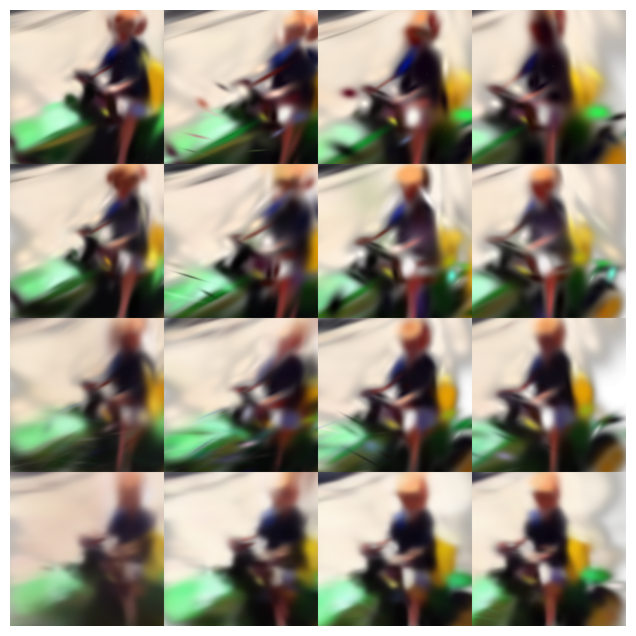

In [4]:
import torch
batch, idx = 99, 3
paths = [
    f"logs/vgmae_base_kinetics_quali/0/tests/0_{batch}_gaussians.pt",
    f"logs/vgmae_base_kinetics_upsample/0/tests/0_{batch}_gaussians.pt",
    f"logs/vgmae_base_kinetics_upsample/1/tests/0_{batch}_gaussians.pt",
    f"logs/vgmae_base_kinetics_upsample/3/tests/0_{batch}_gaussians.pt",]
joineds = []
for path in paths:
    data = torch.load(path, map_location=torch.device('cpu'))
    video = data["renders"][1][::4]
    joined = join_frames_row(video)
    joineds.append(joined)
joined = np.concatenate(joineds, axis=0)


plt.imshow(joined)
plt.axis("off")
plt.gcf().set_size_inches(16*4, 2*4)
plt.show()

In [5]:
import torch
import numpy as np
from moviepy.editor import ImageSequenceClip
import os
BASE_PATH_CONFIG = "/home/tekotan/Chewbacca_test/logs/vgmae_base_kinetics_quali/0/tests/"

videos = []
# for batch, idx in [(16, 2), (21, 0), (48, 1), (57, 3), (79, 2), (95, 1)]:
# for batch, idx in [(79, 2), (34, 0), (61, 1), (70, 3), (91, 2), (38, 1)]:
for batch, idx in [(83, 2), (41, 0), (66, 1), (73, 3), (98, 2), (50, 1)]:
    file_name = f"0_{batch}_gaussians.pt"
    path = os.path.join(BASE_PATH_CONFIG, file_name)
    data = torch.load(path, map_location=torch.device('cpu'))
    render = data["renders"][idx]
    video = data["video"][idx]
    video = np.concatenate((video, render), axis=2)
    videos.append(video)

grid_frames_list = []
for t in range(len(videos[0])):
    # Ensure all frames for stacking have the same H, W for this time step
    # This relies on the h_frame, w_frame determined from the first clip,
    # and subsequent clips being trimmed/resized to match.
    frames_to_stack = [clip[t] for clip in videos]

    row1 = np.hstack((frames_to_stack[0], frames_to_stack[1]))
    row2 = np.hstack((frames_to_stack[2], frames_to_stack[3]))
    row3 = np.hstack((frames_to_stack[4], frames_to_stack[5]))
    grid_frame = np.vstack((row1, row2, row3))
    grid_frames_list.append(grid_frame)

final_video_clip = ImageSequenceClip(grid_frames_list, fps=5)
final_video_clip.write_videofile("renders3.mp4", codec="libx264", audio=False)
print(f"Successfully saved video to renders.mp4")

Moviepy - Building video renders3.mp4.
Moviepy - Writing video renders3.mp4



Moviepy - Done !
Moviepy - video ready renders3.mp4
Successfully saved video to renders.mp4


In [6]:
import torch
import numpy as np
from moviepy.editor import ImageSequenceClip
import os

def generate_simple_grid_video(base_path, batch_idx_pairs, output_filename, fps, radius, thickness, tail, istensor=False):

    all_visualized_clips = []
    min_t = float('inf')
    h_frame, w_frame = -1, -1

    for batch, idx in batch_idx_pairs:
        file_name = f"eval_1_0_{batch}.pt"
        path = os.path.join(base_path, file_name)
        
        data = torch.load(path, map_location=torch.device('cpu'))
        if istensor:
            frames_rgb_np = data["video"][idx].astype(np.uint8)
            tracks_px_np = (data["points_pred"][idx] * 255).numpy().astype(np.uint8) # Assuming conversion from tensor
            occluded_np = data["occlusions_pred"][idx].numpy().astype(np.uint8) # Assuming conversion from tensor
        else:
            frames_rgb_np = data["video"][idx]
            tracks_px_np = data["points_pred"][idx].astype(np.uint8) # Assuming conversion from tensor
            occluded_np = data["occlusions_pred"][idx].astype(np.uint8) # Assuming conversion from tensor
        
        vis_frames_single_clip = overlay_point_tracks(
            frames_rgb_np,
            tracks_px_np,
            occluded_np,
            radius=radius,
            thickness=thickness,
            tail=tail
        )
        
        all_visualized_clips.append(vis_frames_single_clip)
        
        current_t, current_h, current_w, _ = vis_frames_single_clip.shape
        min_t = min(min_t, current_t)

        if h_frame == -1:
            h_frame, w_frame = current_h, current_w
        elif h_frame != current_h or w_frame != current_w:
            print(f"Warning: Frame dimension mismatch. Clip batch {batch}, idx {idx} "
                  f"({current_h}x{current_w}) vs expected ({h_frame}x{w_frame}). "
                  "Grid might look incorrect if dimensions vary significantly. "
                  "Consider resizing frames in overlay_point_tracks or pre-processing.")
            # For simplicity, we'll continue, but this could lead to np.hstack/vstack errors
            # if dimensions are not compatible for stacking. A robust solution would resize.

    if min_t == float('inf') or min_t == 0:
        print("Error: No frames to process or minimum frame count is zero.")
        return

    processed_clips_for_grid = [clip[:min_t, :h_frame, :w_frame, :] for clip in all_visualized_clips]

    grid_frames_list = []
    for t in range(min_t):
        # Ensure all frames for stacking have the same H, W for this time step
        # This relies on the h_frame, w_frame determined from the first clip,
        # and subsequent clips being trimmed/resized to match.
        frames_to_stack = [clip[t, :h_frame, :w_frame, :] for clip in processed_clips_for_grid]
        
        # Adaptive grid: arrange frames in rows of 3
        rows = []
        for i in range(0, len(frames_to_stack), 3):
            row = np.hstack(frames_to_stack[i:i+3])
            rows.append(row)
        grid_frame = np.vstack(rows)
        grid_frames_list.append(grid_frame)

    if not grid_frames_list:
        print("Error: No grid frames were generated.")
        return

    final_video_clip = ImageSequenceClip(grid_frames_list, fps=fps)
    final_video_clip.write_videofile(output_filename, codec="libx264", audio=False)
    print(f"Successfully saved video to {output_filename}")

In [33]:
BASE_PATH_CONFIG = "/home/tekotan/Chewbacca_test/logs/vgmae_base_zeroshot/0/tests-davis/"
BASE_PATH_CONFIG = "/home/tekotan/Chewbacca_test/logs/vgmae_large_seq16_fullfinetune_point_new/0/tests"
# zeroshot davis
# BATCH_IDX_PAIRS_CONFIG = [
#         (13, 0), (6, 1), (10, 0), # Replace with your actual 6 distinct pairs
#         (11, 2), (20, 2), (21, 1),  # Example: (26,4), (27,0), (27,1), (28,2), (28,5)
#         (23, 1), (4, 3), (18, 2)  # Example: (26,4), (27,0), (27,1), (28,2), (28,5)
#     ]

# zeroshot kinetics
# BATCH_IDX_PAIRS_CONFIG = [
#         (37, 2), (76, 1), (83, 0), # Replace with your actual 6 distinct pairs
#         (85, 0), (192, 0), (222, 1),  # Example: (26,4), (27,0), (27,1), (28,2), (28,5)
#         (237, 1), (311, 3), (413, 3)  # Example: (26,4), (27,0), (27,1), (28,2), (28,5)
#     ]

# zeroshot failure cases
# BATCH_IDX_PAIRS_CONFIG = [
#         (14, 1), (20, 0), (21, 3),  # Example: (26,4), (27,0), (27,1), (28,2), (28,5)
#         (23, 0), (26, 3), (8, 2)  # Example: (26,4), (27,0), (27,1), (28,2), (28,5)
#     ]
# finetune davis
# BATCH_IDX_PAIRS_CONFIG = [
#         (35, 6), (35, 0), (23, 1), # Replace with your actual 6 distinct pairs
#         (3, 2), (3, 4), (20, 2),  # Example: (26,4), (27,0), (27,1), (28,2), (28,5)
#         (9, 4), (13, 6), (29, 3)  # Example: (26,4), (27,0), (27,1), (28,2), (28,5)
#     ]
# finetune kinetics
BATCH_IDX_PAIRS_CONFIG = [
        (35, 6), (95, 4), (80, 7), # Replace with your actual 6 distinct pairs
        (3, 2), (12, 4), (20, 2),  # Example: (26,4), (27,0), (27,1), (28,2), (28,5)
        (98, 3), (70, 6), (64, 3)  # Example: (26,4), (27,0), (27,1), (28,2), (28,5)
    ]

OUTPUT_VIDEO_FILENAME_CONFIG = "point_tracks_grid_simple.mp4" # CHANGE AS NEEDED
FPS_CONFIG = 10
RADIUS_CONFIG = 2
THICKNESS_CONFIG = 1
TAIL_CONFIG = True

generate_simple_grid_video(
    base_path=BASE_PATH_CONFIG,
    batch_idx_pairs=BATCH_IDX_PAIRS_CONFIG,
    output_filename=OUTPUT_VIDEO_FILENAME_CONFIG,
    fps=FPS_CONFIG,
    radius=RADIUS_CONFIG,
    thickness=THICKNESS_CONFIG,
    tail=TAIL_CONFIG,
    istensor=True
)

Moviepy - Building video point_tracks_grid_simple.mp4.
Moviepy - Writing video point_tracks_grid_simple.mp4



Moviepy - Done !
Moviepy - video ready point_tracks_grid_simple.mp4
Successfully saved video to point_tracks_grid_simple.mp4


In [ ]:
batch, idx = 26,3

path = f"/home/tekotan/Chewbacca_test/logs/vgmae_base_zeroshot/0/tests/eval_1_0_{batch}.pt"
data = torch.load(path, map_location=torch.device('cpu'))
frames_rgb = data["video"][idx]  # (T, H, W, 3) in RGB uint8
tracks_px = (data["points_pred"][idx]).astype(np.uint8)  # (P, T, 2) in pixels
occluded = data["occlusions_pred"][idx].astype(np.uint8)  # (P, T) occlusion mask (True/1 ⇒ skip)

vis_frames = overlay_point_tracks(frames_rgb, tracks_px, occluded, radius=2, thickness=1, tail=True)

# If you want a single long strip (all frames in a row) for quick inspection:
from numpy import concatenate
strip = concatenate(vis_frames[::2], axis=1)          # (H, T·W, 3)

# Display with matplotlib
import matplotlib.pyplot as plt

plt.imshow(strip)
plt.axis("off")
plt.gcf().set_size_inches(16*4, 2*4)
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/home/tekotan/Chewbacca_test/logs/vgmae_base_zeroshot/0/tests/eval_1_0_26.pt'